In [ ]:
# Cell 1 — install extras (scikit-learn). No TF reinstall.
!pip install -q scikit-learn

# Mount Drive (Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


/tmp/ipython-input-552519409.py:43: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=40, max_width=40, fill_value=0, p=0.25),
Augmenting Sigatoka: 100%|██████████| 473/473 [00:41<00:00, 11.28img/s]



Augmentation finished. Counts (including originals):
  Cordana: 1458 images
  Healthy: 1161 images
  Pestalotiopsis: 1557 images
  Sigatoka: 4257 images


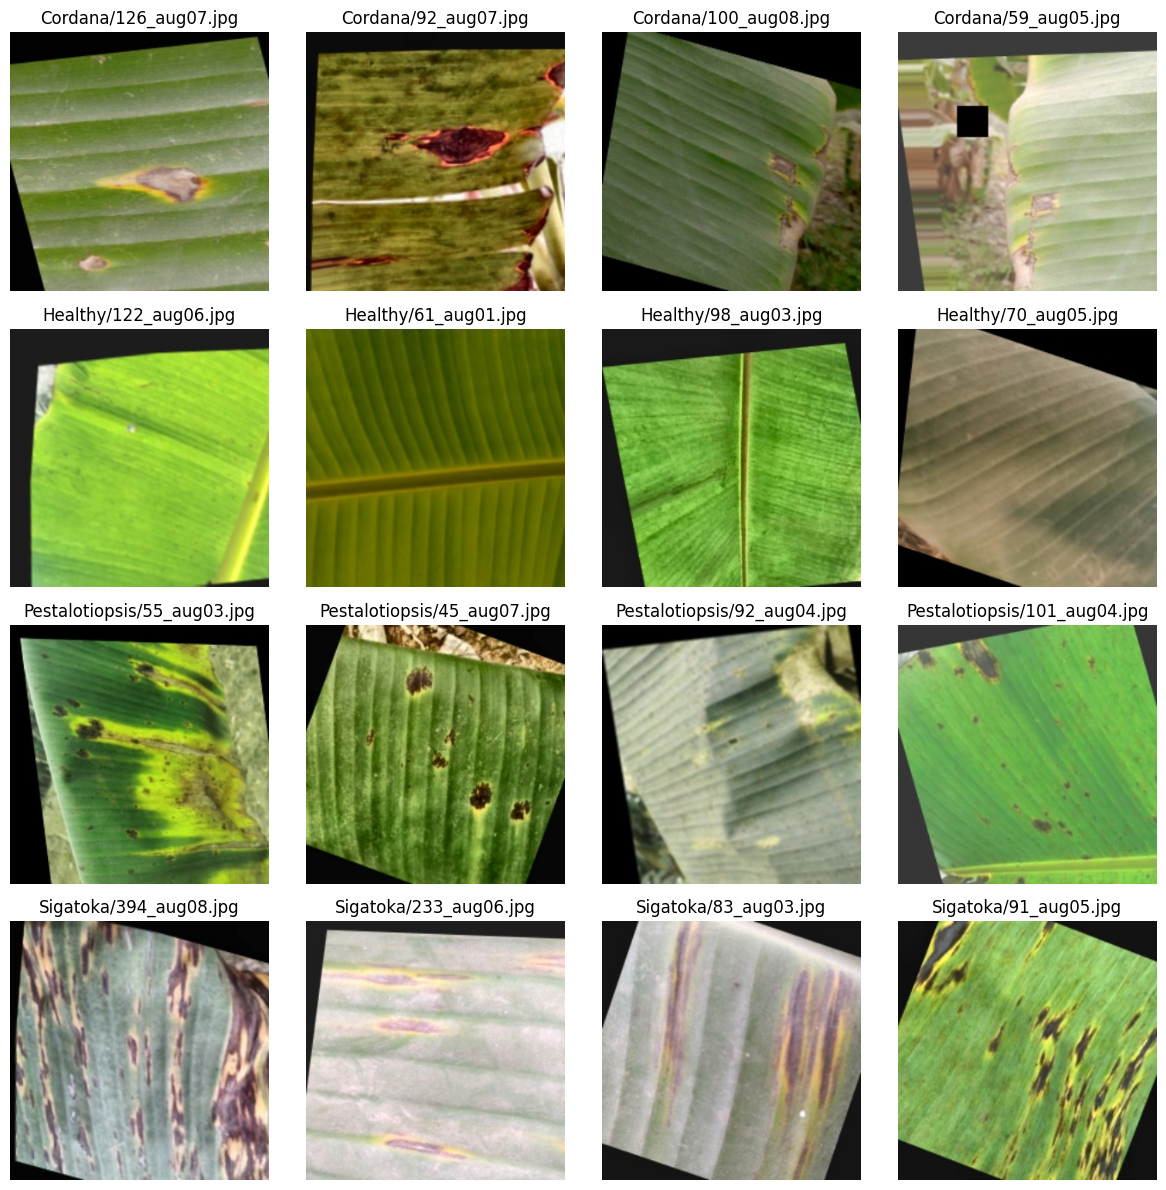


Saved augmented dataset to: /content/drive/MyDrive/DSP/AugmatedImages


In [ ]:
# Augmentation cell (Albumentations v2-safe) — run once
!pip install -q albumentations opencv-python-headless tqdm

import os, random, math
from pathlib import Path
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
SRC_ROOT = Path("/content/drive/MyDrive/DSP/Images")        # source (class subfolders)
DST_ROOT = Path("/content/drive/MyDrive/DSP/AugmatedImages")# destination
CLASS_ORDER = ['Cordana', 'Healthy', 'Pestalotiopsis', 'Sigatoka']
AUG_PER_IMAGE = 8   # 8 augmented images per original
OUT_SIZE = (300, 300)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# ----------------------------

# Prepare destination folders
DST_ROOT.mkdir(parents=True, exist_ok=True)
for cls in CLASS_ORDER:
    (DST_ROOT / cls).mkdir(parents=True, exist_ok=True)

# Albumentations pipeline (v2.x compatible)
aug_pipeline = A.Compose([
    A.OneOf([ A.RandomRotate90(p=0.5), A.Rotate(limit=25, p=0.5) ], p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Transpose(p=0.2),
    A.Affine(translate_percent=0.06, scale=(0.9,1.1), rotate=(-15,15), shear=(-8,8), p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.OneOf([
        A.MotionBlur(blur_limit=3, p=0.3),
        A.MedianBlur(blur_limit=3, p=0.2),
        A.GaussianBlur(blur_limit=3, p=0.2)
    ], p=0.25),
    A.CLAHE(clip_limit=3.0, p=0.2),
    A.CoarseDropout(max_holes=1, max_height=40, max_width=40, fill_value=0, p=0.25),
    A.Resize(height=OUT_SIZE[0], width=OUT_SIZE[1], p=1.0),
], p=1.0)

# helper read function robust to unicode paths
def read_image_rgb(path):
    # read reliably even with unicode names
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def imwrite_rgb(path, rgb_img):
    bgr = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
    ext = os.path.splitext(path)[1] or '.jpg'
    ok, enc = cv2.imencode(ext, bgr)
    if not ok:
        raise IOError(f"Failed to encode {path}")
    enc.tofile(path)

summary = {}
# iterate classes
for cls in CLASS_ORDER:
    src_cls = SRC_ROOT / cls
    dst_cls = DST_ROOT / cls
    if not src_cls.exists() or not src_cls.is_dir():
        print(f"Warning: missing source folder {src_cls}; skipping class {cls}")
        summary[cls] = 0
        continue

    files = [f for f in sorted(src_cls.iterdir()) if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']]
    if len(files) == 0:
        print(f"No images found in {src_cls}; skipping.")
        summary[cls] = 0
        continue

    cnt = 0
    # copy resized originals first
    for orig in files:
        try:
            img = read_image_rgb(orig)
            img_resized = cv2.resize(img, OUT_SIZE, interpolation=cv2.INTER_AREA)
            dst_name = f"{orig.stem}_orig{orig.suffix if orig.suffix else '.jpg'}"
            imwrite_rgb(str(dst_cls / dst_name), img_resized)
            cnt += 1
        except Exception as e:
            print("Skip original:", orig.name, "error:", e)

    # create augmentations
    for orig in tqdm(files, desc=f"Augmenting {cls}", unit="img"):
        try:
            img = read_image_rgb(orig)
        except Exception as e:
            print("Unreadable image, skipping:", orig, e)
            continue

        for k in range(AUG_PER_IMAGE):
            # deterministic-ish seed per image+k for reproducibility
            seed_val = (hash(str(orig)) + k + SEED) & 0xFFFFFFFF
            np.random.seed(seed_val)
            random.seed(seed_val)

            sample = aug_pipeline(image=img)
            aug_img = sample['image']
            fname = f"{orig.stem}_aug{k+1:02d}.jpg"
            try:
                imwrite_rgb(str(dst_cls / fname), aug_img)
                cnt += 1
            except Exception as e:
                print("Failed to save:", fname, e)

    summary[cls] = cnt

# Print results
print("\nAugmentation finished. Counts (including originals):")
for cls, c in summary.items():
    print(f"  {cls}: {c} images")

# show sample images (up to 16)
SAMPLES_TO_SHOW = 16
sample_paths = []
for cls in CLASS_ORDER:
    imgs = sorted((DST_ROOT / cls).glob("*"))
    if imgs:
        sample_paths.extend(random.sample(list(imgs), min(4, len(imgs))))

if len(sample_paths) > SAMPLES_TO_SHOW:
    sample_paths = random.sample(sample_paths, SAMPLES_TO_SHOW)

n = len(sample_paths)
if n == 0:
    print("No augmented images found to display.")
else:
    cols = 4
    rows = math.ceil(n/cols)
    plt.figure(figsize=(12, 3*rows))
    for i, p in enumerate(sample_paths):
        try:
            img = read_image_rgb(p)
            plt.subplot(rows, cols, i+1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{p.parent.name}/{p.name}")
        except Exception as e:
            print("Preview load failed for", p, e)
    plt.tight_layout()
    plt.show()

print("\nSaved augmented dataset to:", DST_ROOT)


Found 8433 files belonging to 4 classes.
Total Batches: 528
Train: 422 batches
Val: 52 batches
Test: 54 batches


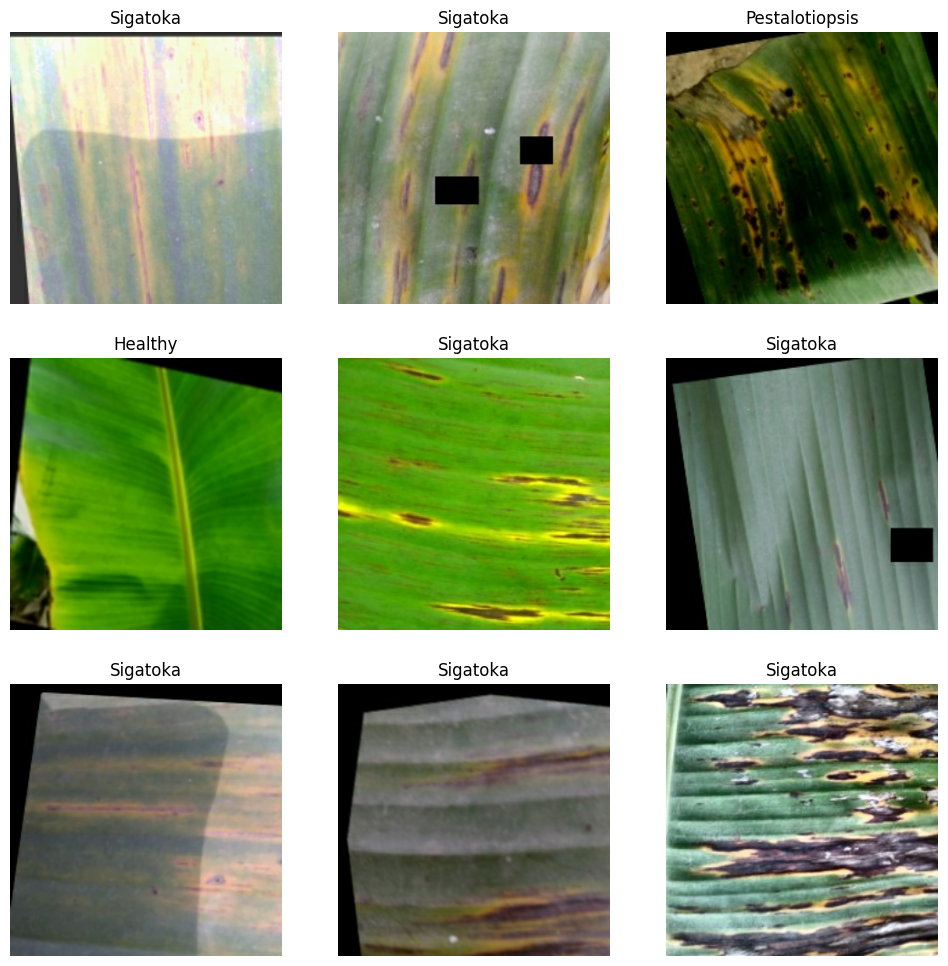

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

# -------- CONFIG --------
AUG_PATH = "/content/drive/MyDrive/DSP/AugmatedImages"
CLASS_NAMES = ['Cordana', 'Healthy', 'Pestalotiopsis', 'Sigatoka']
IMG_SIZE = (300, 300)
BATCH_SIZE = 16   # Reduced to avoid RAM crash
SEED = 42
# ------------------------

# Create dataset from augmented folder
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    AUG_PATH,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    batch_size=BATCH_SIZE
)

# Split into train/val/test (80/10/10)
ds_size = full_ds.cardinality().numpy()
train_size = int(0.8 * ds_size)
val_size = int(0.1 * ds_size)

train_ds = full_ds.take(train_size)
temp_ds = full_ds.skip(train_size)
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

# Prefetch only (no .cache() to avoid RAM overload)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print(f"Total Batches: {ds_size}")
print(f"Train: {train_size} batches")
print(f"Val: {val_size} batches")
print(f"Test: {ds_size - train_size - val_size} batches")

# ---------- Show sample batch ----------
def show_batch(dataset):
    images, labels = next(iter(dataset))
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[tf.argmax(labels[i]).numpy()])
        plt.axis("off")

show_batch(train_ds)


In [ ]:
# Enable mixed precision for faster GPU training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

IMG_SHAPE = (300, 300, 3)
NUM_CLASSES = 4

def build_cnn():
    model = models.Sequential([
        layers.Input(shape=IMG_SHAPE),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.35),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.40),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.45),

        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')  # float32 output for stability
    ])

    return model

model = build_cnn()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 300, 300, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    21,233,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,820,068 (83.24 MB)

 Trainable params: 21,818,596 (83.23 MB)

 Non-trainable params: 1,472 (5.75 KB)

Augmented dataset counts (per class): {'Cordana': 1458, 'Healthy': 1161, 'Pestalotiopsis': 1557, 'Sigatoka': 4257}
Using class_weight: {0: 1.4459876543209877, 1: 1.815891472868217, 2: 1.3540462427745665, 3: 0.4952431289640592}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 300, 300, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    21,233,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,820,068 (83.24 MB)

 Trainable params: 21,818,596 (83.23 MB)

...

422/422 ━━━━━━━━━━━━━━━━━━━━ 153s 310ms/step - accuracy: 0.9586 - loss: 0.6475 - val_accuracy: 0.9459 - val_loss: 0.6625 - learning_rate: 5.0000e-04
Epoch 18/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9597 - loss: 0.6389
Epoch 18: val_accuracy did not improve from 0.94591
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.9597 - loss: 0.6389 - val_accuracy: 0.8654 - val_loss: 0.9264 - learning_rate: 5.0000e-04
Epoch 19/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9588 - loss: 0.6437
Epoch 19: val_accuracy did not improve from 0.94591
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 111ms/step - accuracy: 0.9588 - loss: 0.6437 - val_accuracy: 0.9399 - val_loss: 0.7101 - learning_rate: 5.0000e-04
Epoch 20/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9710 - loss: 0.6121
Epoch 20: val_accuracy improved from 0.94591 to 0.96154, saving model to /content/drive/MyDrive/DSP/custom_cnn_best_aug.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 157s 320ms/step - accuracy: 0.9710 - loss: 0.6121 - val_accuracy: 0.9615 - val_loss: 0.6139 - learning_rate: 5.0000e-04
Epoch 21/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9672 - loss: 0.6005
Epoch 21: val_accuracy did not improve from 0.96154
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.9672 - loss: 0.6005 - val_accuracy: 0.9507 - val_loss: 0.6535 - learning_rate: 5.0000e-04
Epoch 22/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9664 - loss: 0.5857
Epoch 22: val_accuracy did not improve from 0.96154
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 112ms/step - accuracy: 0.9664 - loss: 0.5857 - val_accuracy: 0.9411 - val_loss: 0.6548 - learning_rate: 5.0000e-04
Epoch 23/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9803 - loss: 0.5556
Epoch 23: val_accuracy did not improve from 0.96154
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.9803 - loss: 0.5556 - val_accuracy: 0.9519 - val_loss: 0.6291 - learning_rate

422/422 ━━━━━━━━━━━━━━━━━━━━ 152s 310ms/step - accuracy: 0.9712 - loss: 0.5566 - val_accuracy: 0.9663 - val_loss: 0.5464 - learning_rate: 2.5000e-04
Epoch 26/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9857 - loss: 0.4909
Epoch 26: val_accuracy improved from 0.96635 to 0.96875, saving model to /content/drive/MyDrive/DSP/custom_cnn_best_aug.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 169s 320ms/step - accuracy: 0.9857 - loss: 0.4909 - val_accuracy: 0.9688 - val_loss: 0.5143 - learning_rate: 2.5000e-04
Epoch 27/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9845 - loss: 0.4646
Epoch 27: val_accuracy did not improve from 0.96875
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 115ms/step - accuracy: 0.9845 - loss: 0.4645 - val_accuracy: 0.8870 - val_loss: 0.6320 - learning_rate: 2.5000e-04
Epoch 28/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9909 - loss: 0.4275
Epoch 28: val_accuracy improved from 0.96875 to 0.98077, saving model to /content/drive/MyDrive/DSP/custom_cnn_best_aug.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 149s 301ms/step - accuracy: 0.9908 - loss: 0.4275 - val_accuracy: 0.9808 - val_loss: 0.4363 - learning_rate: 2.5000e-04
Epoch 29/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9887 - loss: 0.4104
Epoch 29: val_accuracy did not improve from 0.98077
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 117ms/step - accuracy: 0.9887 - loss: 0.4104 - val_accuracy: 0.9712 - val_loss: 0.4367 - learning_rate: 2.5000e-04
Epoch 30/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9885 - loss: 0.3927
Epoch 30: val_accuracy did not improve from 0.98077
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 114ms/step - accuracy: 0.9885 - loss: 0.3927 - val_accuracy: 0.9651 - val_loss: 0.4314 - learning_rate: 2.5000e-04
Epoch 31/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9876 - loss: 0.3848
Epoch 31: val_accuracy did not improve from 0.98077
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 110ms/step - accuracy: 0.9876 - loss: 0.3848 - val_accuracy: 0.9700 - val_loss: 0.4269 - learning_rate

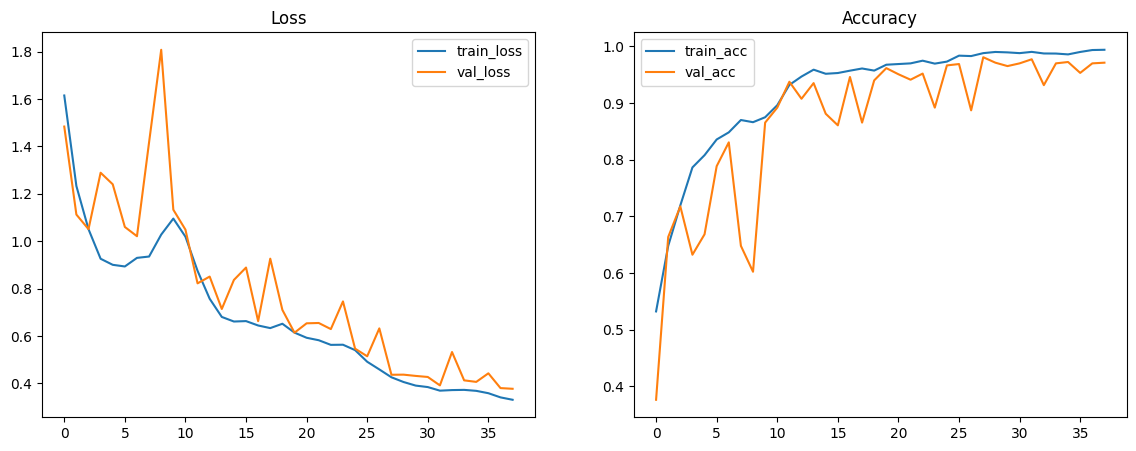

Best checkpoint saved to: /content/drive/MyDrive/DSP/custom_cnn_best_aug.h5
Training log saved to: /content/drive/MyDrive/DSP/training_log_aug.csv


In [ ]:
# Cell 4 — Training setup + fit (AdamW, LR schedule, EarlyStopping, checkpoint, plots)
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from keras.optimizers import AdamW
import tensorflow as tf

# ---- config ----
AUG_PATH = "/content/drive/MyDrive/DSP/AugmatedImages"
CLASS_ORDER = ['Cordana', 'Healthy', 'Pestalotiopsis', 'Sigatoka']
CHECKPOINT_PATH = "/content/drive/MyDrive/DSP/custom_cnn_best_aug.h5"
LOG_CSV = "/content/drive/MyDrive/DSP/training_log_aug.csv"
EPOCHS = 60           # phase 1; we'll reduce LR and continue if needed
# -----------------

# Compute class weights from augmented train split (we split earlier from the full augmented dataset)
# Safer approach: count files per class in AUG_PATH and use inverse-frequency weighting
def count_images_in_folder(root, class_order):
    counts = {}
    for cls in class_order:
        p = Path(root) / cls
        if not p.exists():
            counts[cls] = 0
        else:
            counts[cls] = len([f for f in p.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']])
    return counts

counts = count_images_in_folder(AUG_PATH, CLASS_ORDER)
print("Augmented dataset counts (per class):", counts)
total = sum(counts.values())
class_weight = {}
for i, cls in enumerate(CLASS_ORDER):
    c = counts.get(cls, 0)
    class_weight[i] = (total / (len(CLASS_ORDER) * c)) if c > 0 else 1.0
print("Using class_weight:", class_weight)

# Recreate/compile model (in case of session changes)
# 'model' should exist from previous cell; if not, import build function or rebuild here.
try:
    model
except NameError:
    # If model name not found, rebuild using the same function definition used earlier
    from tensorflow.keras import layers, models, regularizers
    IMG_SHAPE = (300,300,3)
    NUM_CLASSES = 4
    def build_cnn():
        m = models.Sequential([
            layers.Input(shape=IMG_SHAPE),
            layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Dropout(0.25),

            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Dropout(0.30),

            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Dropout(0.35),

            layers.Conv2D(256, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.40),

            layers.Flatten(),
            layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.45),
            layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
        ])
        return m
    model = build_cnn()

# Optimizer and loss
initial_lr = 1e-3
weight_decay = 1e-5
opt = AdamW(learning_rate=initial_lr, weight_decay=weight_decay)
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)

model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.CSVLogger(LOG_CSV)
]

# Fit the model
history = model.fit(
    train_ds,                 # from earlier cell: dataset created from AUG_PATH and split
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

# Plot training curves
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')

plt.show()

# Save final model (best saved by checkpoint already)
print("Best checkpoint saved to:", CHECKPOINT_PATH)
print("Training log saved to:", LOG_CSV)


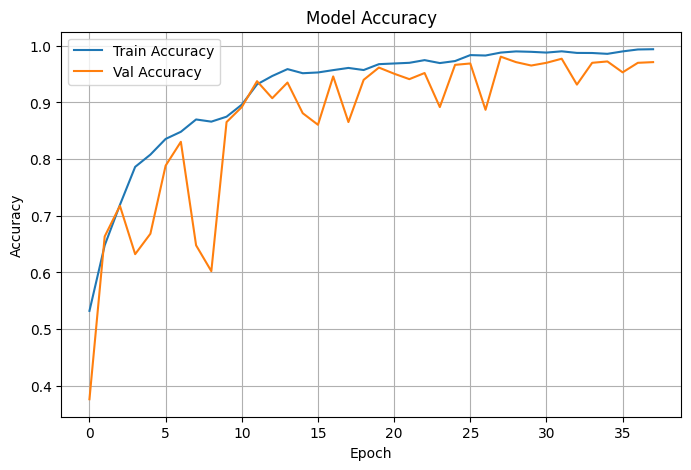

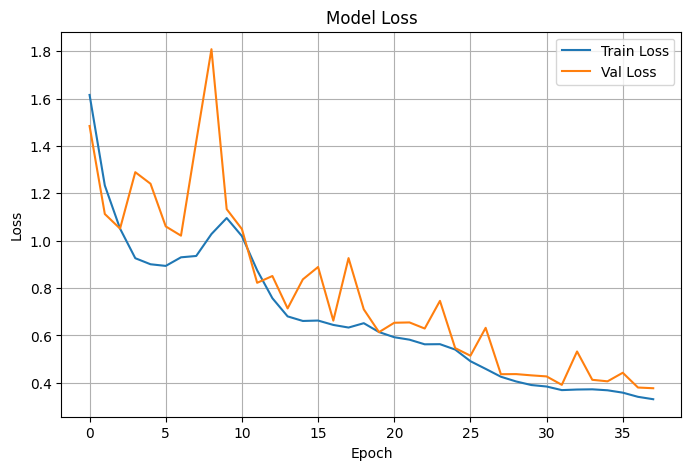

✅ Plots generated from saved CSV


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

LOG_CSV = "/content/drive/MyDrive/DSP/training_log_aug.csv"

# Load training log
log = pd.read_csv(LOG_CSV)

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(log['accuracy'], label='Train Accuracy')
plt.plot(log['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(log['loss'], label='Train Loss')
plt.plot(log['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("✅ Plots generated from saved CSV")


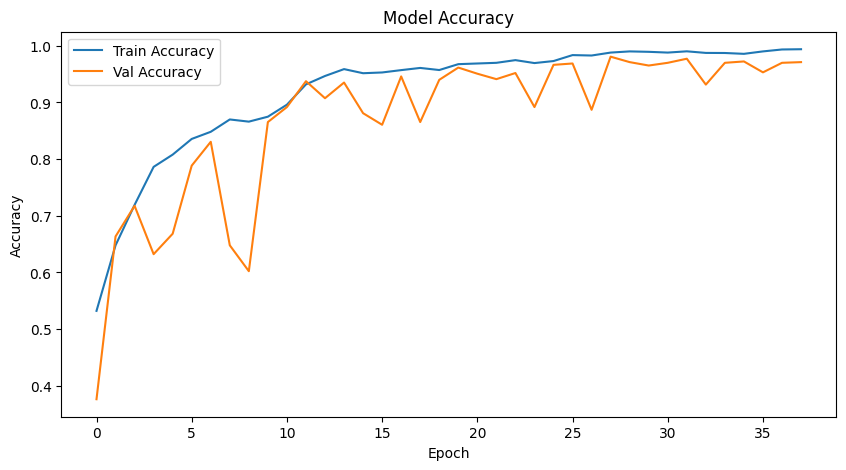

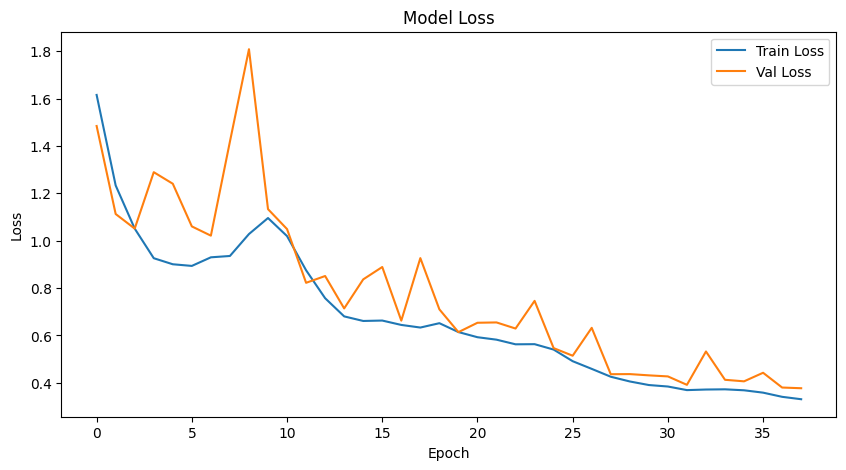

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import itertools

# Get true labels & predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Print report
print(classification_report(y_true, y_pred, target_names=class_names))


NameError: name 'test_ds' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import itertools
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


NameError: name 'y_true' is not defined

In [ ]:
model.save("banana_disease_model.h5")

In [ ]:
# Simple Linear Regression Program

import numpy as np
from sklearn.linear_model import LinearRegression

# Input data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 6])

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Output results
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# Prediction
y_pred = model.predict([7])
print("Predicted values:", y_pred)


Slope (Coefficient): 0.8000000000000002
Intercept: 1.7999999999999998


ValueError: Expected 2D array, got 1D array instead:
array=[7].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.